In [ ]:
!pip install datasets pillow matplotlib transformers tqdm accelerate

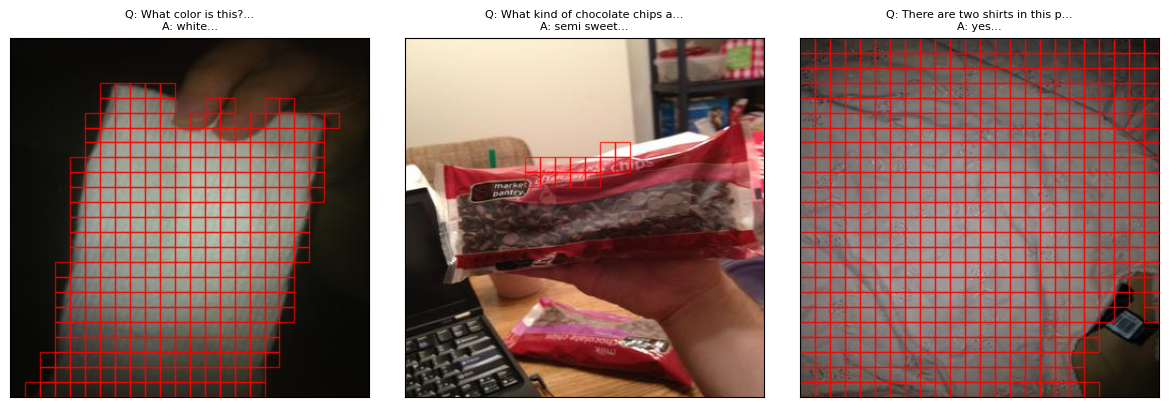

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt

ds = load_dataset("patrickamadeus/vizwiz336-p14-grounding-1k", split="train")
def visualize_dataset_samples(dataset, num_samples=5):
    sample_indices = list(range(min(num_samples, len(dataset))))
    fig, axes = plt.subplots(1, num_samples, figsize=(4*num_samples, 4))
    if num_samples == 1:
        axes = [axes]
    
    for idx, sample_idx in enumerate(sample_indices):
        sample = dataset[sample_idx]
        image = sample['image']
        
        axes[idx].imshow(image)
        width, height = 336,336
        patch_size = 14
        patches_per_dim = width // patch_size
        
        patch_gt = sample.get('patch_gt', [])
        for patch_idx in patch_gt:
            row = patch_idx // patches_per_dim
            col = patch_idx % patches_per_dim
            rect_x = col * patch_size - 0.5
            rect_y = row * patch_size - 0.5
            rect_width = patch_size
            rect_height = patch_size
            
            from matplotlib.patches import Rectangle
            rect = Rectangle((rect_x, rect_y), rect_width, rect_height, 
                           linewidth=1, edgecolor='red', facecolor='none', alpha=0.7)
            axes[idx].add_patch(rect)
        
        question = sample.get('question', 'No question')
        answer = sample.get('most_common_answer', 'No answer')
        axes[idx].set_title(f"Q: {question[:30]}...\nA: {answer[:30]}...", fontsize=8)
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])
    
    plt.tight_layout()
    plt.show()
visualize_dataset_samples(ds, num_samples=3)

In [ ]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration
import math
import numpy as np

DEVICE = None

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(DEVICE)

model = LlavaForConditionalGeneration.from_pretrained("llava-hf/llava-1.5-7b-hf", dtype=torch.bfloat16, device_map=DEVICE, attn_implementation="eager")
processor = AutoProcessor.from_pretrained("llava-hf/llava-1.5-7b-hf")

In [4]:
def process_single_sample(model, processor, image, question, final_answer_tokens=30):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        },
    ]

    inputs = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    ).to(DEVICE, torch.bfloat16)

    with torch.no_grad():
        gen_output = model.generate(
            **inputs,
            max_new_tokens=final_answer_tokens,
            do_sample=False,
            output_attentions=True,
            return_dict_in_generate=True
        )

    # Extract output text
    input_ids = inputs['input_ids'][0].tolist()
    gen_ids = gen_output.sequences
    trimmed_ids = [out[len(inp):] for inp, out in zip(inputs.input_ids, gen_ids)]
    output_text = processor.batch_decode(trimmed_ids, skip_special_tokens=True)[0].strip()

    # Return both generated text and attentions
    return output_text, gen_output.attentions, input_ids, inputs['pixel_values']

def extract_visual_attention(model, attentions, input_ids):
    """Extract attention maps for visual tokens (patches)"""
    image_token_id = model.config.image_token_index
    input_ids_tensor = torch.tensor(input_ids)
    image_token_positions = (input_ids_tensor == image_token_id).nonzero(as_tuple=True)[0]
    
    if len(image_token_positions) == 0:
        return None
    
    # Get visual token range
    visual_start = image_token_positions[0].item()
    visual_seq_length = model.config.image_seq_length  # 576 for LLaVA
    visual_end = visual_start + visual_seq_length
    
    # Extract visual attention from last layer, last generated token
    # attentions is a tuple of (num_generated_tokens,) where each element is (num_layers, batch_size, num_heads, seq_len, seq_len)
    last_token_attns = attentions[-1]  # Last generated token
    # Average layers 15-25
    layers_to_average = last_token_attns[15:26]  # Layers 15-25 (inclusive)
    last_layer_attn = torch.stack(layers_to_average).mean(dim=0)  # Average over layers
    
    # Get attention from last generated token to visual tokens
    visual_attn = last_layer_attn[0, :, -1, visual_start:visual_end]  # [num_heads, visual_seq_length]
    
    # Average over heads
    visual_attn_avg = visual_attn.mean(dim=0)  # [visual_seq_length]
    
    # Reshape to patch grid (24x24 for LLaVA)
    patch_grid_size = int(visual_seq_length ** 0.5)
    visual_attn_2d = visual_attn_avg.reshape(patch_grid_size, patch_grid_size)
    
    return visual_attn_2d.cpu().float().numpy()

def extract_visual_attention_strongest(model, attentions, input_ids):
    """Extract attention maps for visual tokens (patches) - get strongest attention for each patch across all layers and all generated tokens"""
    image_token_id = model.config.image_token_index
    input_ids_tensor = torch.tensor(input_ids)
    image_token_positions = (input_ids_tensor == image_token_id).nonzero(as_tuple=True)[0]
    
    if len(image_token_positions) == 0:
        return None
    
    # Get visual token range
    visual_start = image_token_positions[0].item()
    visual_seq_length = model.config.image_seq_length  # 576 for LLaVA
    visual_end = visual_start + visual_seq_length
    
    # Extract visual attention across ALL generated tokens and ALL layers
    # attentions is a tuple of (num_generated_tokens,) where each element is (num_layers, batch_size, num_heads, seq_len, seq_len)
    
    all_tokens_layers_visual_attn = []
    
    # Iterate through all generated tokens
    for token_idx in range(len(attentions)):
        token_attns = attentions[token_idx]  # All layers for this token
        
        # Get attention from this generated token to visual tokens for ALL layers
        for layer_idx in range(len(token_attns)):
            layer_attn = token_attns[layer_idx]  # [batch_size, num_heads, seq_len, seq_len]
            visual_attn = layer_attn[0, :, -1, visual_start:visual_end]  # [num_heads, visual_seq_length]
            # Average over heads for this layer and token
            visual_attn_avg = visual_attn.mean(dim=0)  # [visual_seq_length]
            all_tokens_layers_visual_attn.append(visual_attn_avg)
    
    # Stack all tokens and layers: [num_tokens * num_layers, visual_seq_length]
    all_tokens_layers_visual_attn = torch.stack(all_tokens_layers_visual_attn)
    
    # For each patch, get the maximum attention across all tokens and all layers
    max_attention_per_patch = all_tokens_layers_visual_attn.max(dim=0)[0]  # [visual_seq_length]
    
    # Reshape to patch grid (24x24 for LLaVA)
    patch_grid_size = int(visual_seq_length ** 0.5)
    visual_attn_2d = max_attention_per_patch.reshape(patch_grid_size, patch_grid_size)
    
    return visual_attn_2d.cpu().float().numpy()

  0%|          | 0/5 [00:00<?, ?it/s]

Sample 0:
Question: What color is this?
Response: The color of this is white.
Ground truth patches: [78, 79, 80, 81, 82, 102, 103, 104, 105, 106, 109, 110, 113, 114, 125, 126, 127, 128, 129, 130, 132, 133, 134, 136, 137, 138, 139, 140, 141, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 363, 364, 365, 366, 367,

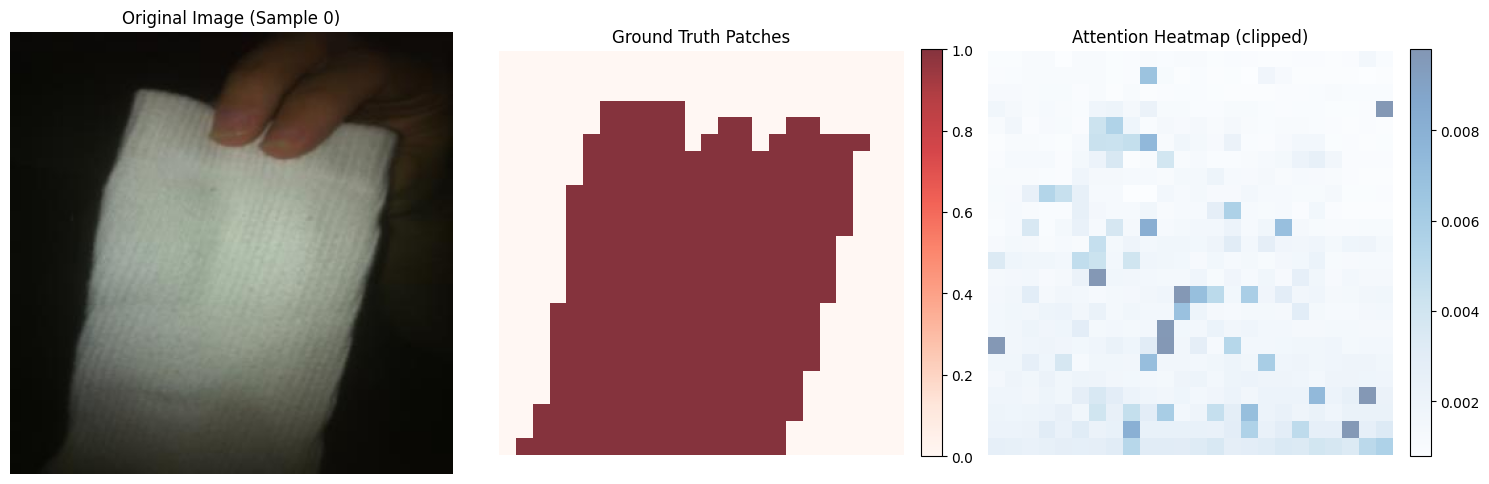

 20%|██        | 1/5 [00:00<00:03,  1.06it/s]

Sample 1:
Question: What kind of chocolate chips are these?
Response: These chocolate chips are made from dark chocolate.
Ground truth patches: [181, 182, 200, 201, 202, 203, 204, 205, 206, 224, 225, 226, 227, 228]



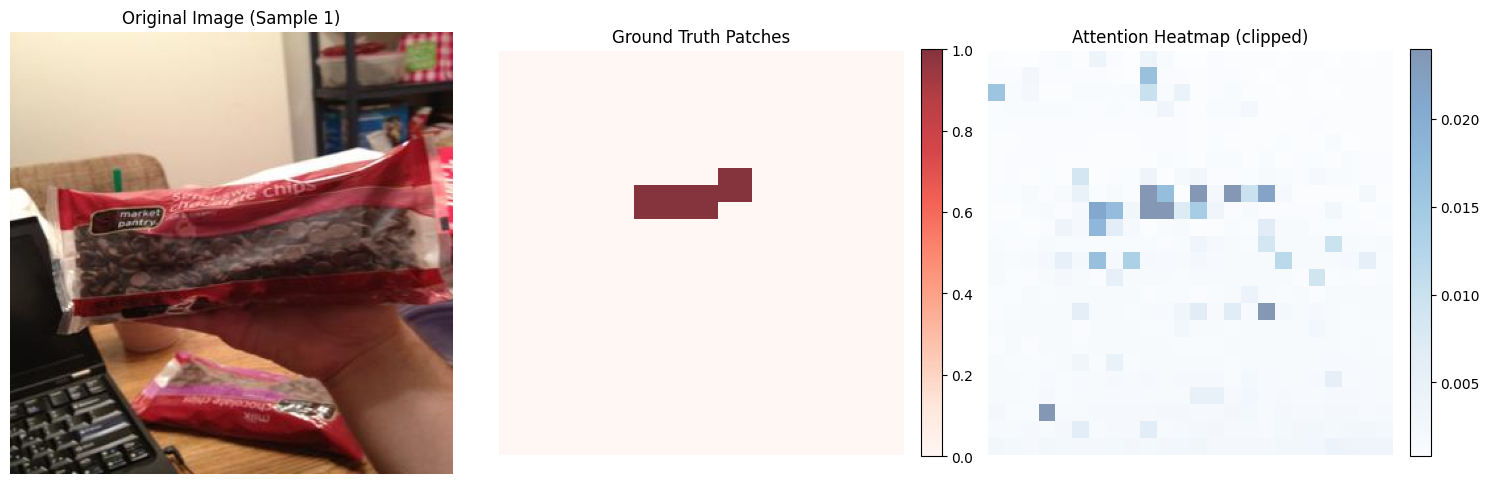

 40%|████      | 2/5 [00:01<00:02,  1.10it/s]

Sample 2:
Question: There are two shirts in this picture hopefully, are they the same color?
Response: Yes, both shirts in the image are the same color.
Ground truth patches: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186,

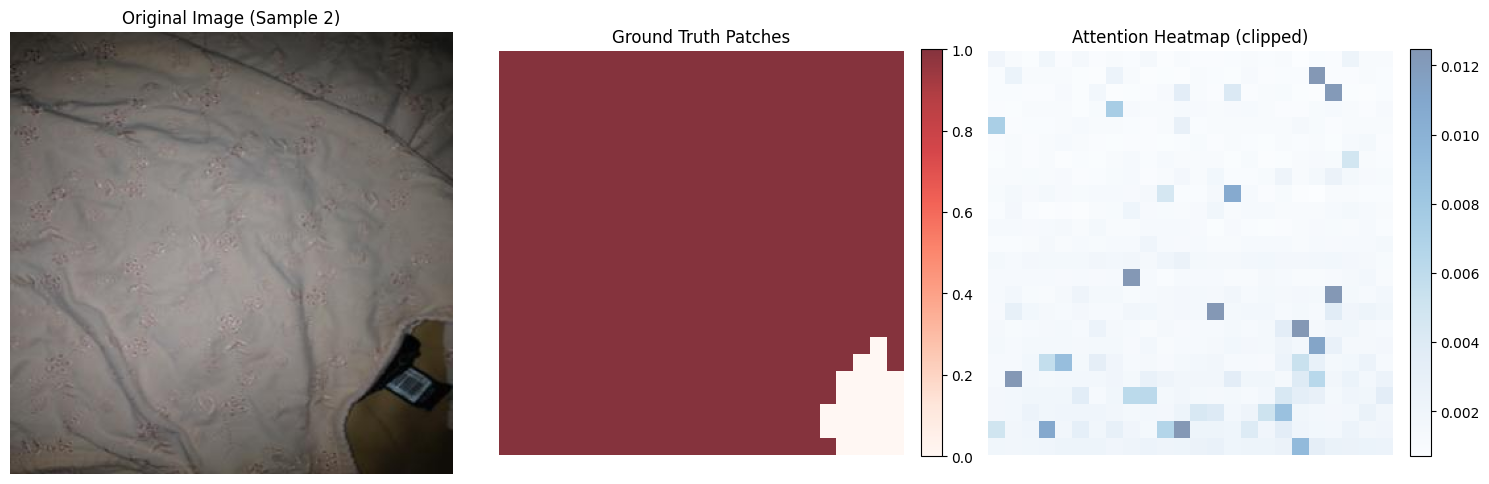

 60%|██████    | 3/5 [00:02<00:01,  1.14it/s]

Sample 3:
Question: Can you read some of the text on the green?
Response: Yes, I can read some of the text on the green. The text reads "The Hardware/Software Interface."
Ground truth patches: [112, 113, 114, 115, 116, 117, 118, 119, 136, 137, 138, 139, 140, 141, 142, 143, 160, 161, 162, 163, 164, 165, 166, 167, 186, 187, 188, 189, 190, 191]



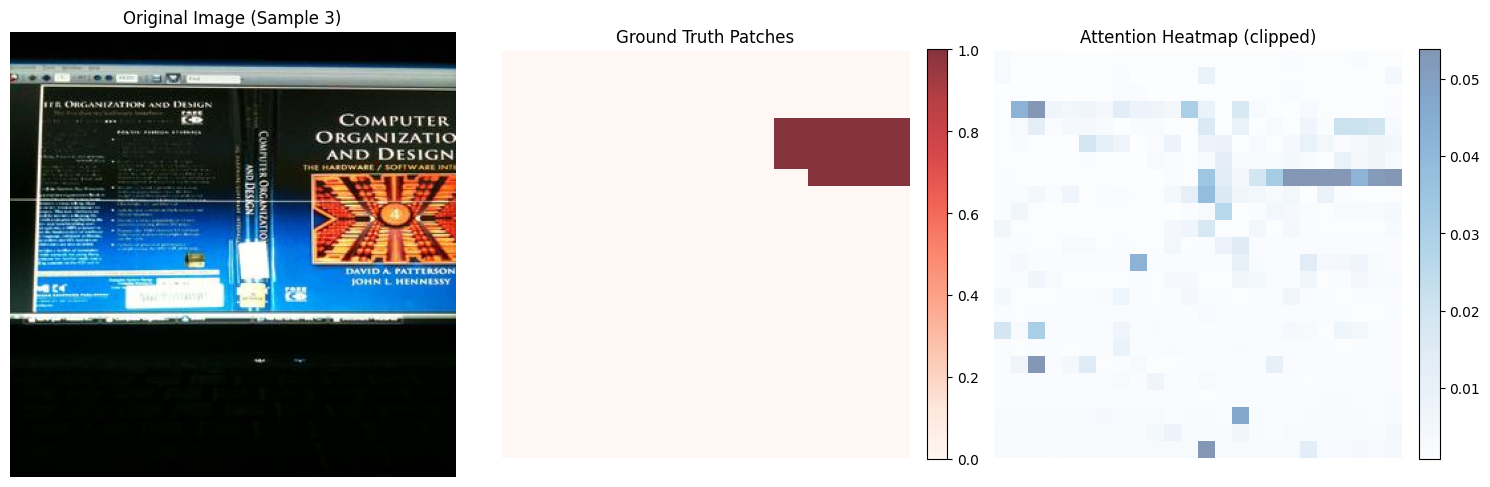

 80%|████████  | 4/5 [00:03<00:01,  1.01s/it]

Sample 4:
Question: what is in this picture?
Response: The image features a laptop computer with its keyboard and screen visible. The laptop is open and sitting on a desk. The keyboard is positioned towards
Ground truth patches: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179,

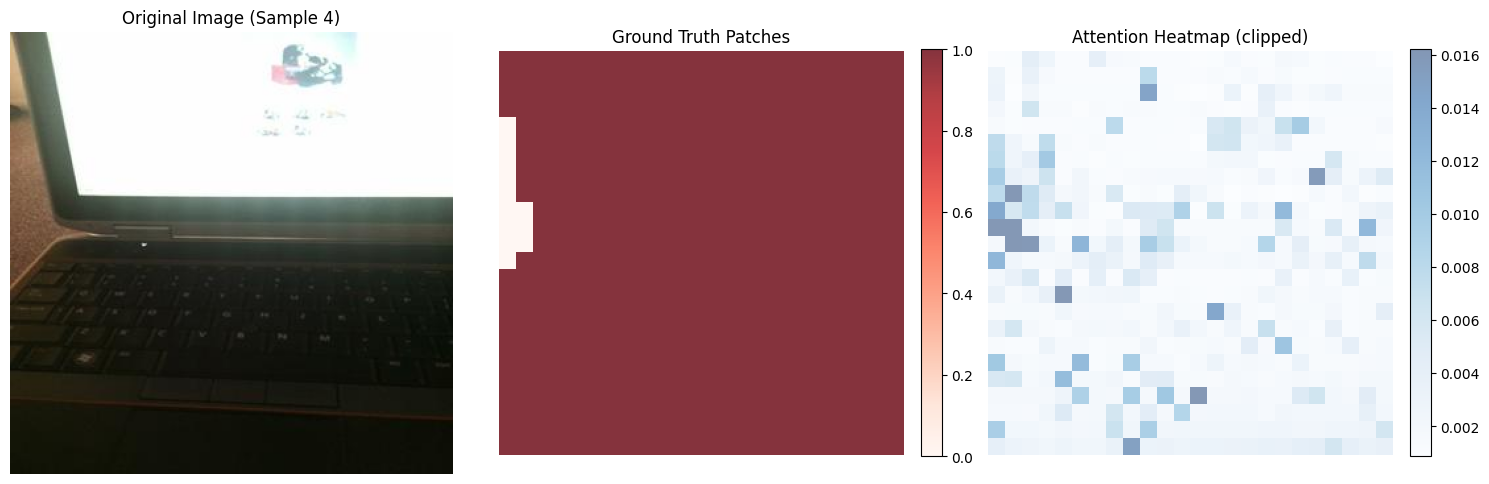

100%|██████████| 5/5 [00:05<00:00,  1.04s/it]


In [6]:
from tqdm import tqdm

for i in tqdm(range(5), total = 5):
    sample = ds[i]
    image = sample['image']
    question = sample['question']
    response, attns, input_ids, pixel_values = process_single_sample(model, processor, image, question)
    print(f"Sample {i}:")
    print(f"Question: {question}")
    print(f"Response: {response}")
    print(f"Ground truth patches: {sample.get('patch_gt', [])}")
    print()

    visual_attention = extract_visual_attention_strongest(model, attns, input_ids)
    if visual_attention is not None:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(image)
        axes[0].set_title(f'Original Image (Sample {i})')
        axes[0].axis('off')
        
        patch_grid_size = int(visual_attention.shape[0])
        gt_mask = np.zeros((patch_grid_size, patch_grid_size))
        if 'patch_gt' in sample and sample['patch_gt']:
            for patch_idx in sample['patch_gt']:
                row = patch_idx // patch_grid_size
                col = patch_idx % patch_grid_size
                gt_mask[row, col] = 1
        
        im1 = axes[1].imshow(gt_mask, cmap='Reds', alpha=0.8)
        axes[1].set_title('Ground Truth Patches')
        axes[1].axis('off')
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
        
        attention_limit = np.percentile(visual_attention, 99)
        visual_attention_clipped = np.clip(visual_attention, 0, attention_limit)
        
        im2 = axes[2].imshow(visual_attention_clipped, cmap='Blues', alpha=0.5)
        axes[2].set_title('Attention Heatmap (clipped)')
        axes[2].axis('off')
        plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
        
        plt.tight_layout()
        plt.show()

In [ ]:
import json
import os
from pathlib import Path

output_dir = Path("./run")
output_dir.mkdir(exist_ok=True)

output_file = output_dir / "inference.jsonl"

with open(output_file, 'w') as f:
    for i in tqdm(range(len(ds)), desc="Inference..."):
        sample = ds[i]
        image = sample['image']
        question = sample['question']
        
        try:
            response, attns, input_ids, pixel_values = process_single_sample(model, processor, image, question)
            visual_attention = extract_visual_attention_strongest(model, attns, input_ids)
            
            result_entry = {
                "index": i,
                "response": response
            }
            
            if visual_attention is not None:
                result_entry["attention"] = visual_attention.flatten().tolist()
            else:
                result_entry["attention"] = None
            f.write(json.dumps(result_entry) + '\n')
            
        except Exception as e:
            print(f"Error processing sample {i}: {str(e)}")
            result_entry = {
                "index": i,
                "response": None,
                "attention": None,
                "error": str(e)
            }
            f.write(json.dumps(result_entry) + '\n')

Inference...:   5%|▍         | 49/1000 [00:37<14:37,  1.08it/s]

In [7]:
len(ds)

1000

In [13]:
import json
import os
from pathlib import Path

def extract_attention_by_modality(model, attentions, input_ids):
    """Extract attention maps split by modality: visual and non-visual tokens"""
    image_token_id = model.config.image_token_index
    input_ids_tensor = torch.tensor(input_ids)
    image_token_positions = (input_ids_tensor == image_token_id).nonzero(as_tuple=True)[0]
    
    total_seq_len = len(input_ids)
    
    if len(image_token_positions) == 0:
        # No image tokens - all are non-visual
        visual_range = None
        non_visual_range = (0, total_seq_len)
    else:
        # Get visual token range
        visual_start = image_token_positions[0].item()
        visual_seq_length = model.config.image_seq_length  # 576 for LLaVA
        visual_end = visual_start + visual_seq_length
        
        visual_range = (visual_start, visual_end)
        # Non-visual tokens are everything else (system + text)
        non_visual_indices = list(range(0, visual_start)) + list(range(visual_end, total_seq_len))
    
    # Extract attention from last layer, last generated token
    last_token_attns = attentions[-1]  # Last generated token
    
    # Store attention for each layer
    visual_attention_layers = []
    non_visual_attention_layers = []
    
    for layer_idx, layer_attn in enumerate(last_token_attns):
        # Get attention from last generated token to all input tokens
        full_attn = layer_attn[0, :, -1, :]  # [num_heads, total_seq_len]
        
        # Average over heads
        full_attn_avg = full_attn.mean(dim=0)  # [total_seq_len]
        
        # Extract attention for each modality
        visual_attention = None
        non_visual_attention = None
        
        if visual_range is not None and visual_range[1] > visual_range[0]:
            visual_attn = full_attn_avg[visual_range[0]:visual_range[1]]
            # Reshape to patch grid (24x24 for LLaVA)
            patch_grid_size = int(model.config.image_seq_length ** 0.5)
            visual_attention = visual_attn.reshape(patch_grid_size, patch_grid_size).cpu().float().numpy()
        
        if len(image_token_positions) == 0:
            # All tokens are non-visual
            non_visual_attention = full_attn_avg.cpu().float().numpy()
        else:
            # Extract non-visual tokens
            non_visual_attention = full_attn_avg[non_visual_indices].cpu().float().numpy()
        
        visual_attention_layers.append(visual_attention)
        non_visual_attention_layers.append(non_visual_attention)
    
    return visual_attention_layers, non_visual_attention_layers

output_dir = Path("./run")
output_dir.mkdir(exist_ok=True)

output_file = output_dir / "inference_all.jsonl"

with open(output_file, 'w') as f:
    for i in tqdm(range(len(ds)), desc="Inference..."):
        sample = ds[i]
        image = sample['image']
        question = sample['question']
        
        try:
            response, attns, input_ids, pixel_values = process_single_sample(model, processor, image, question)
            
            # Extract attention split by modality
            visual_attention_layers, non_visual_attention_layers = extract_attention_by_modality(model, attns, input_ids)
            
            result_entry = {
                "index": i,
                "response": response
            }
            
            # Store attention for each layer
            visual_attention_data = []
            for layer_idx, visual_attention in enumerate(visual_attention_layers):
                if visual_attention is not None:
                    visual_attention_data.append({
                        "layer": layer_idx,
                        "attention": visual_attention.flatten().tolist()
                    })
                else:
                    visual_attention_data.append({
                        "layer": layer_idx,
                        "attention": None
                    })
            
            non_visual_attention_data = []
            for layer_idx, non_visual_attention in enumerate(non_visual_attention_layers):
                if non_visual_attention is not None:
                    non_visual_attention_data.append({
                        "layer": layer_idx,
                        "attention": non_visual_attention.flatten().tolist()
                    })
                else:
                    non_visual_attention_data.append({
                        "layer": layer_idx,
                        "attention": None
                    })
            
            result_entry["visual_attention_layers"] = visual_attention_data
            result_entry["non_visual_attention_layers"] = non_visual_attention_data
                
            f.write(json.dumps(result_entry) + '\n')
            
        except Exception as e:
            print(f"Error processing sample {i}: {str(e)}")
            result_entry = {
                "index": i,
                "response": None,
                "visual_attention_layers": None,
                "non_visual_attention_layers": None,
                "error": str(e)
            }
            f.write(json.dumps(result_entry) + '\n')

Inference...: 100%|██████████| 1000/1000 [12:59<00:00,  1.28it/s]


In [14]:
import json
import numpy as np
from pathlib import Path

inference_file = output_dir / "inference.jsonl"
results = []

with open(inference_file, 'r') as f:
    for line in f:
        results.append(json.loads(line.strip()))

correct = 0
total = 0
correct_attention_scores = []
wrong_attention_scores = []

for result in results:
    index = result['index']
    response = result.get('response')
    attentions = result.get('attention', [])
    
    if response is None:
        continue
    
    sample = ds[index]
    answers = sample['answers']
    
    response_lower = response.lower()
    is_correct = any(answer.lower() in response_lower for answer in answers)
    
    final_attention_score = 0
    
    if len(attentions) == 576:
        attention_99th = np.percentile(attentions, 95)
        clipped_attentions = np.clip(attentions, None, attention_99th)
        
        ground_truth_patches = sample.get('patch_gt', [])
        
        for attn_idx, clipped_attn_value in enumerate(clipped_attentions):
            if attn_idx in ground_truth_patches:
                final_attention_score += clipped_attn_value
            else:
                final_attention_score -= clipped_attn_value
    
    if is_correct:
        correct += 1
        correct_attention_scores.append(final_attention_score)
    else:
        wrong_attention_scores.append(final_attention_score)
    
    total += 1

accuracy = correct / total if total > 0 else 0
print(f"Accuracy: {correct}/{total} = {accuracy:.4f} ({accuracy*100:.2f}%)")

if correct_attention_scores:
    avg_correct_attention = np.mean(correct_attention_scores)
    print(f"Average attention score for correct answers: {avg_correct_attention:.4f}")
else:
    print("No correct answers to calculate attention score")

if wrong_attention_scores:
    avg_wrong_attention = np.mean(wrong_attention_scores)
    print(f"Average attention score for wrong answers: {avg_wrong_attention:.4f}")
else:
    print("No wrong answers to calculate attention score")

print(f"Total samples processed: {total}")


Accuracy: 740/1000 = 0.7400 (74.00%)
Average attention score for correct answers: -0.1324
Average attention score for wrong answers: -0.4592
Total samples processed: 1000


In [17]:
import json
import numpy as np
from pathlib import Path
from tqdm import tqdm

# Load inference results
inference_file = output_dir / "inference_all.jsonl"
results = []

with open(inference_file, 'r') as f:
    for line in f:
        results.append(json.loads(line.strip()))

PERCENTILE = 99

# Calculate accuracy and attention rewards
correct = 0
total = 0
correct_attention_scores = []
wrong_attention_scores = []
correct_visual_proportions = []
wrong_visual_proportions = []

for result in tqdm(results, desc="Processing results"):
    index = result['index']
    response = result.get('response')
    visual_attn_layers = result.get('visual_attention_layers', [])
    non_visual_attn_layers = result.get('non_visual_attention_layers', [])

    
    if response is None:
        continue

    strongest_attention = []
    if visual_attn_layers:
        num_patches = len(visual_attn_layers[0]["attention"]) if visual_attn_layers[0].get("attention") else 0
        
        if num_patches > 0:
            strongest_attention = list(visual_attn_layers[0]["attention"])
            for layer in visual_attn_layers[1:]:
                layer_attention = layer.get("attention", [])
                if len(layer_attention) == num_patches:
                    for patch_idx in range(num_patches):
                        strongest_attention[patch_idx] = max(strongest_attention[patch_idx], layer_attention[patch_idx])
    
    attentions = strongest_attention
    
    # Get the corresponding dataset sample
    sample = ds[index]
    answers = sample['answers']
    ground_truth_patches = sample.get('patch_gt', [])
    
    response_lower = response.lower()
    is_correct = any(answer.lower() in response_lower for answer in answers)
    
    final_attention_score = 0
    
    if len(attentions) == 576:
        attention_99th = np.percentile(attentions, PERCENTILE)
        clipped_attentions = np.clip(attentions, None, attention_99th)
        
        for attn_idx, clipped_attn_value in enumerate(clipped_attentions):
            if attn_idx in ground_truth_patches:
                final_attention_score += clipped_attn_value
            else:
                final_attention_score -= clipped_attn_value
    

    visual_sum = 0
    non_visual_sum = 0

    # Calculate visual attention sum only for ground truth patches
    for layer in visual_attn_layers:
        layer_attention = layer.get("attention", [])
        if layer_attention:
            # Clip to 99th percentile to prevent attention sink bloating
            attention_99th = np.percentile(layer_attention, PERCENTILE)
            clipped_layer_attention = np.clip(layer_attention, None, attention_99th)
            
            for patch_idx, attn_value in enumerate(clipped_layer_attention):
                if patch_idx in ground_truth_patches:
                    visual_sum += attn_value
                else:
                    non_visual_sum += attn_value

    # Calculate non-visual attention sum with smart clipping
    for layer in non_visual_attn_layers:
        layer_attention = layer.get("attention", [])
        if layer_attention:
            # Clip to 99th percentile to prevent attention sink bloating
            attention_99th = np.percentile(layer_attention, PERCENTILE)
            clipped_layer_attention = np.clip(layer_attention, None, attention_99th)
            non_visual_sum += sum(clipped_layer_attention)
    
    visual_proportion = visual_sum / (visual_sum + non_visual_sum) if (visual_sum + non_visual_sum) > 0 else 0

    
    if is_correct:
        correct += 1
        correct_attention_scores.append(final_attention_score)
        correct_visual_proportions.append(visual_proportion)
    else:
        wrong_attention_scores.append(final_attention_score)
        wrong_visual_proportions.append(visual_proportion)
    
    total += 1

# Calculate and print accuracy
accuracy = correct / total if total > 0 else 0
print(f"Accuracy: {correct}/{total} = {accuracy:.4f} ({accuracy*100:.2f}%)")

print()

# Calculate and print attention score statistics
if correct_attention_scores:
    avg_correct_attention = np.mean(correct_attention_scores)
    print(f"Average attention score for correct answers: {avg_correct_attention:.4f}")
else:
    print("No correct answers to calculate attention score")

if wrong_attention_scores:
    avg_wrong_attention = np.mean(wrong_attention_scores)
    print(f"Average attention score for wrong answers: {avg_wrong_attention:.4f}")
else:
    print("No wrong answers to calculate attention score")
print()
# Calculate and print visual attention proportion statistics
if correct_visual_proportions:
    avg_correct_visual_prop = np.mean(correct_visual_proportions)
    print(f"Average visual attention proportion for correct answers: {avg_correct_visual_prop:.4f} ({avg_correct_visual_prop*100:.2f}%)")
else:
    print("No correct answers to calculate visual attention proportion")

if wrong_visual_proportions:
    avg_wrong_visual_prop = np.mean(wrong_visual_proportions)
    print(f"Average visual attention proportion for wrong answers: {avg_wrong_visual_prop:.4f} ({avg_wrong_visual_prop*100:.2f}%)")
else:
    print("No wrong answers to calculate visual attention proportion")

print(f"Total samples processed: {total}")

Processing results: 100%|██████████| 1000/1000 [00:26<00:00, 37.33it/s]

Accuracy: 740/1000 = 0.7400 (74.00%)

Average attention score for correct answers: -0.1500
Average attention score for wrong answers: -0.3144

Average visual attention proportion for correct answers: 0.0562 (5.62%)
Average visual attention proportion for wrong answers: 0.0431 (4.31%)
Total samples processed: 1000


In [18]:
import json
import numpy as np
from pathlib import Path
from tqdm import tqdm

# Load inference results
inference_file = output_dir / "inference_all.jsonl"
results = []

with open(inference_file, 'r') as f:
    for line in f:
        results.append(json.loads(line.strip()))

PERCENTILE = 99

# Stats containers
correct = 0
total = 0
correct_attention_scores = []
wrong_attention_scores = []
correct_visual_fidelity = []
wrong_visual_fidelity = []
correct_multimodal_fidelity = []
wrong_multimodal_fidelity = []

for result in tqdm(results, desc="Processing results"):
    index = result['index']
    response = result.get('response')
    visual_attn_layers = result.get('visual_attention_layers', [])
    non_visual_attn_layers = result.get('non_visual_attention_layers', [])

    if response is None:
        continue

    # Aggregate strongest attention across visual layers
    strongest_attention = []
    if visual_attn_layers:
        num_patches = len(visual_attn_layers[0]["attention"]) if visual_attn_layers[0].get("attention") else 0
        if num_patches > 0:
            strongest_attention = list(visual_attn_layers[0]["attention"])
            for layer in visual_attn_layers[1:]:
                layer_attention = layer.get("attention", [])
                if len(layer_attention) == num_patches:
                    for patch_idx in range(num_patches):
                        strongest_attention[patch_idx] = max(
                            strongest_attention[patch_idx], layer_attention[patch_idx]
                        )
    attentions = strongest_attention

    # Get dataset sample
    sample = ds[index]
    answers = sample['answers']
    ground_truth_patches = sample.get('patch_gt', [])

    response_lower = response.lower()
    is_correct = any(answer.lower() in response_lower for answer in answers)

    # ----------------------------
    # Final attention reward score
    # ----------------------------
    final_attention_score = 0
    if len(attentions) == 576:
        attention_99th = np.percentile(attentions, PERCENTILE)
        clipped_attentions = np.clip(attentions, None, attention_99th)
        for attn_idx, clipped_attn_value in enumerate(clipped_attentions):
            if attn_idx in ground_truth_patches:
                final_attention_score += clipped_attn_value
            else:
                final_attention_score -= clipped_attn_value

    # ----------------------------
    # Fidelity metrics
    # ----------------------------
    visual_sum = 0
    non_gt_visual_sum = 0

    # Split visual attention into gt vs non-gt patches
    for layer in visual_attn_layers:
        layer_attention = layer.get("attention", [])
        if layer_attention:
            attention_99th = np.percentile(layer_attention, PERCENTILE)
            clipped_layer_attention = np.clip(layer_attention, None, attention_99th)

            for patch_idx, attn_value in enumerate(clipped_layer_attention):
                if patch_idx in ground_truth_patches:
                    visual_sum += attn_value
                else:
                    non_gt_visual_sum += attn_value

    # Non-visual token attention
    non_visual_sum = 0
    for layer in non_visual_attn_layers:
        layer_attention = layer.get("attention", [])
        if layer_attention:
            attention_99th = np.percentile(layer_attention, PERCENTILE)
            clipped_layer_attention = np.clip(layer_attention, None, attention_99th)
            non_visual_sum += sum(clipped_layer_attention)

    # Visual-only fidelity (within image patches)
    visual_fidelity = visual_sum / (visual_sum + non_gt_visual_sum) if (visual_sum + non_gt_visual_sum) > 0 else 0

    # Multimodal fidelity (vs text + other tokens)
    multimodal_fidelity = visual_sum / (visual_sum + non_gt_visual_sum + non_visual_sum) if (visual_sum + non_gt_visual_sum + non_visual_sum) > 0 else 0

    # ----------------------------
    # Collect stats
    # ----------------------------
    if is_correct:
        correct += 1
        correct_attention_scores.append(final_attention_score)
        correct_visual_fidelity.append(visual_fidelity)
        correct_multimodal_fidelity.append(multimodal_fidelity)
    else:
        wrong_attention_scores.append(final_attention_score)
        wrong_visual_fidelity.append(visual_fidelity)
        wrong_multimodal_fidelity.append(multimodal_fidelity)

    total += 1

# ----------------------------
# Reporting
# ----------------------------
accuracy = correct / total if total > 0 else 0
print(f"Accuracy: {correct}/{total} = {accuracy:.4f} ({accuracy*100:.2f}%)\n")

# Attention reward stats
if correct_attention_scores:
    print(f"Average attention score (correct): {np.mean(correct_attention_scores):.4f}")
if wrong_attention_scores:
    print(f"Average attention score (wrong): {np.mean(wrong_attention_scores):.4f}")
print()

# Visual fidelity (image-only grounding)
if correct_visual_fidelity:
    avg_correct_vf = np.mean(correct_visual_fidelity)
    print(f"Visual Fidelity (correct): {avg_correct_vf:.4f} ({avg_correct_vf*100:.2f}%)")
if wrong_visual_fidelity:
    avg_wrong_vf = np.mean(wrong_visual_fidelity)
    print(f"Visual Fidelity (wrong): {avg_wrong_vf:.4f} ({avg_wrong_vf*100:.2f}%)")
print()

# Multimodal fidelity (image vs text+patch balance)
if correct_multimodal_fidelity:
    avg_correct_mf = np.mean(correct_multimodal_fidelity)
    print(f"Multimodal Fidelity (correct): {avg_correct_mf:.4f} ({avg_correct_mf*100:.2f}%)")
if wrong_multimodal_fidelity:
    avg_wrong_mf = np.mean(wrong_multimodal_fidelity)
    print(f"Multimodal Fidelity (wrong): {avg_wrong_mf:.4f} ({avg_wrong_mf*100:.2f}%)")

print(f"\nTotal samples processed: {total}")

Processing results: 100%|██████████| 1000/1000 [00:26<00:00, 37.54it/s]

Accuracy: 740/1000 = 0.7400 (74.00%)

Average attention score (correct): -0.1500
Average attention score (wrong): -0.3144

Visual Fidelity (correct): 0.4250 (42.50%)
Visual Fidelity (wrong): 0.3204 (32.04%)

Multimodal Fidelity (correct): 0.0562 (5.62%)
Multimodal Fidelity (wrong): 0.0431 (4.31%)

Total samples processed: 1000
